In [2]:
# Data reading
import pandas as pd
import sys


from tqdm import tqdm

DF_FOLDER_PATH = "../../code snippets-with-labels&metrics"
GRANULARITIES = ['file', 'class', 'method', 'block']

# got this list ffrom the authors github repository
PROJECTS = [
    "antlr4-4.11.0", "dbeaver-22.2.5", "elasticsearch-8.5.2", "exoplayer-2.18.2",
    "fastjson-1.2.83", "flink-1.15.3", "guava-31.1", "jenkins-2.379", "libgdx-1.11.0", 
    "logstash-8.5.2", "mockito-4.9.0", "openrefine-3.6.2", "presto-0.278", 
    "quarkus-2.14.0", "questdb-6.6", "redisson-3.18.1", "rxjava-3.1.5", "tink-1.7.0"
]


from pathlib import Path

def find_file(folder_path, prefix):
    # folder.glob('prefix*') looks for anything starting with the prefix
    folder = Path(folder_path)
    return next(folder.glob(f"{prefix}*"))



# granularity -> project -> dataframe
data = {}

for granularity in tqdm(GRANULARITIES):
    data[granularity] = {}
    

    for project in PROJECTS:
        
        all_projects_folder_path = f"{DF_FOLDER_PATH}/{granularity}/"
        project_file = find_file(folder_path=all_projects_folder_path, prefix=project.lower())
        
        project_df = pd.read_csv(project_file)
        project_name = project.split("-")[0]
        data[granularity][project_name] = project_df

100%|██████████| 4/4 [00:14<00:00,  3.51s/it]


In [3]:
data, GRANULARITIES, PROJECTS

sys.path.append("../..")
from project_Info import file_feature_names_lowercase, class_feature_names_lowercase, method_feature_names_lowercase, block_feature_names_lowercase 

features = {
    "file": file_feature_names_lowercase,
    "class": class_feature_names_lowercase,
    "method": method_feature_names_lowercase,
    "block": block_feature_names_lowercase
}

In [4]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier

sys.path.append("../../LiteM/")
from ASMOTE import ASMOTE

RANDOM_STATE = 1

def ten_folds(df, granularity, k_fold = 10):
    df.columns = df.columns.str.lower()

    # 1. Separate your features (X) from your target variable (y)
    X = df[features[granularity]]
    y = df['CommentsAssociatedLabel'.lower()]

    skf = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=RANDOM_STATE)

    f1_scores = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=12, n_estimators=500, learning_rate=0.05, verbose=-1)
        tech = ASMOTE(random_state=RANDOM_STATE, clf=LGBMClassifier(random_state=RANDOM_STATE))
        
        X_train_resample, y_train_resample = tech.fit_resample(X_train, y_train)

        model.fit(X_train_resample, y_train_resample)

        # predict
        y_pred = model.predict(X_test)
        # y_pred_prob = model.predict_proba(X_test)[:, 1]

        f1 = f1_score(y_test, y_pred)

        f1_scores.append(f1)

    mean_f1_score = sum(f1_scores) / k_fold

    return mean_f1_score


In [5]:
from tqdm import tqdm # or from tqdm.notebook import tqdm

import warnings
import logging

# Silence Python warnings
warnings.filterwarnings("ignore")

# Silence LightGBM's internal logger
logger = logging.getLogger('lightgbm')
logger.setLevel(logging.ERROR)

f1s = {}
for granularity in tqdm(GRANULARITIES, desc="Granularities"):
    f1s[granularity] = {}
    
    for project in tqdm(data[granularity].keys(), desc=f"Projects ({granularity})", leave=False):
        df = data[granularity][project]
        f1_result = ten_folds(df=df, granularity=granularity, k_fold=10)
        
        f1s[granularity][project] = f1_result
        
        # Use tqdm.write instead of print()
        tqdm.write(str(f1_result))

Granularities:   0%|          | 0/4 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 48, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1012
[LightGBM] [Info] Number of data points in the train set: 399, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120301 -> initscore=-1.989585
[LightGBM] [Info] Start training from score -1.989585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

                                                    
Granularities:   0%|          | 0/4 [00:17<?, ?it/s]   

0.33768065268065267


                                                    
Granularities:   0%|          | 0/4 [00:47<?, ?it/s]           

...

0.8278854478854478


                                                             
Granularities:  75%|███████▌  | 3/4 [27:32<06:58, 418.40s/it]    

0.5156100795755968


                                                             
Granularities: 100%|██████████| 4/4 [27:51<00:00, 417.81s/it]    

0.2012987012987013


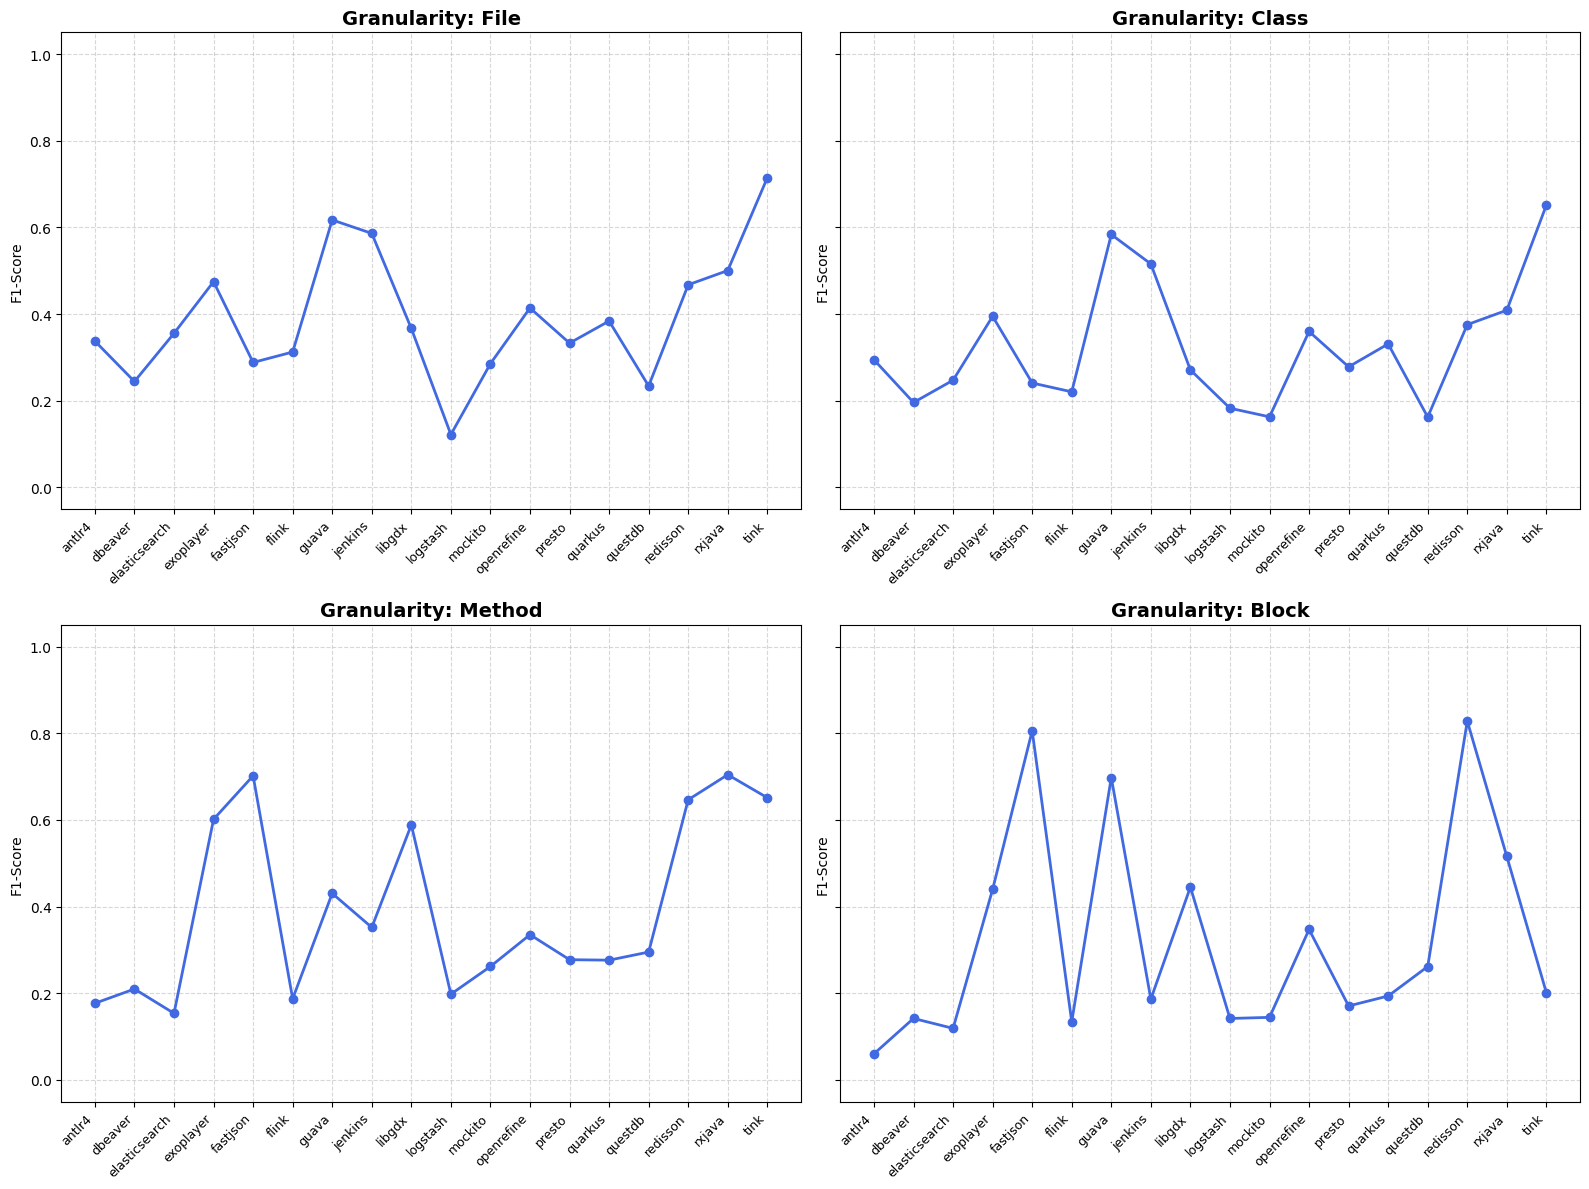

In [6]:
import matplotlib.pyplot as plt

# Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Loop through each granularity and its assigned subplot axis
for ax, granularity in zip(axes, f1s.keys()):
    projects = list(f1s[granularity].keys())
    scores = list(f1s[granularity].values())
    
    # Plot the line chart
    ax.plot(projects, scores, marker='o', color='royalblue', linewidth=2, markersize=6)
    
    ax.set_title(f"Granularity: {granularity.capitalize()}", fontsize=14, fontweight='bold')
    ax.set_ylabel("F1-Score")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Rotate project names so they don't overlap on the X-axis
    ax.set_xticklabels(projects, rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
import pickle

# Save the dictionary to a pickle file
with open('f1_results_LightGBM.pkl', 'wb') as f:
    pickle.dump(f1s, f)

print("Dictionary saved to f1_results.pkl")

Dictionary saved to f1_results.pkl
